In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [2]:
nav = pd.read_csv(r"D:\BlueStock_Project\Data\Processed\02_nav_history_cleaned_1.csv")
nav['date'] = pd.to_datetime(nav['date'])
nav = nav.sort_values(['amfi_code', 'date']).reset_index(drop=True)

print("Data loaded. Shape:", nav.shape)

Data loaded. Shape: (46000, 3)


### Daily Returns

Daily Returns Summary:
count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


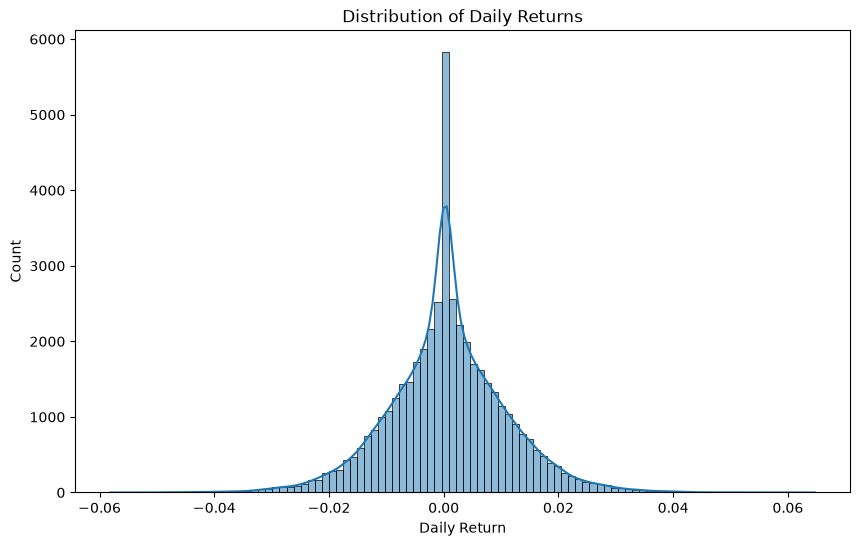

In [7]:
nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

print("Daily Returns Summary:")
print(nav['daily_return'].describe())

# Distribution check
plt.figure(figsize=(10,6))
sns.histplot(nav['daily_return'].dropna(), bins=100, kde=True)
plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.show()

### CAGR Table

In [9]:
def calculate_cagr(group, years):
    group = group.sort_values('date')
    if len(group) < 30:  # Need sufficient data
        return np.nan
    start_nav = group['nav'].iloc[0]
    end_nav = group['nav'].iloc[-1]
    return (end_nav / start_nav) ** (1 / years) - 1

cagr_data = []
for code, group in nav.groupby('amfi_code'):
    cagr_data.append({
        'amfi_code': code,
        'CAGR_1yr': calculate_cagr(group, 1),
        'CAGR_3yr': calculate_cagr(group, 3),
        'CAGR_5yr': calculate_cagr(group, 5)
    })

cagr_df = pd.DataFrame(cagr_data)
print("Top 10 Funds by 3-Year CAGR:")
print(cagr_df.sort_values('CAGR_3yr', ascending=False).head(10).round(4))

Top 10 Funds by 3-Year CAGR:
    amfi_code  CAGR_1yr  CAGR_3yr  CAGR_5yr
25     120505    2.4868    0.5164    0.2838
21     119598    2.4404    0.5096    0.2803
39     149324    2.4249    0.5074    0.2792
36     148569    2.3866    0.5017    0.2763
34     148567    2.2778    0.4855    0.2680
30     120843    2.2705    0.4844    0.2674
2      100033    2.1851    0.4713    0.2607
38     149323    2.1272    0.4623    0.2561
16     119094    1.9846    0.4398    0.2445
19     119551    1.7456    0.4003    0.2238


### Sharpe and Sortino Ratio

In [10]:
rf = 0.065 / 252  # Daily risk free rate

def sharpe_ratio(returns):
    return (returns.mean() - rf) / returns.std() * np.sqrt(252) if returns.std() != 0 else np.nan

def sortino_ratio(returns):
    downside = returns[returns < 0]
    return (returns.mean() - rf) / downside.std() * np.sqrt(252) if len(downside) > 0 else np.nan

metrics = nav.groupby('amfi_code')['daily_return'].agg([sharpe_ratio, sortino_ratio]).reset_index()
metrics = metrics.rename(columns={'sharpe_ratio': 'Sharpe', 'sortino_ratio': 'Sortino'})
print(metrics.sort_values('Sharpe', ascending=False).head(10))

    amfi_code    Sharpe   Sortino
34     148567  1.448291  2.385644
30     120843  1.306744  2.364320
36     148569  1.234930  2.146914
19     119551  1.208267  2.140267
25     120505  1.180101  2.029353
38     149323  1.132122  1.875101
2      100033  1.093699  1.829134
9      118632  1.081659  1.850133
3      101206  1.027213  1.799563
24     120504  1.026524  1.805294


### Alpha and Beta

In [11]:
benchmark = nav[nav['amfi_code'] == 100016].copy()  # Example
benchmark = benchmark.rename(columns={'daily_return': 'bench_return'})

alpha_beta = []
for code, group in nav.groupby('amfi_code'):
    merged = group.merge(benchmark[['date', 'bench_return']], on='date', how='inner')
    if len(merged) > 30:
        slope, intercept, _, _, _ = stats.linregress(merged['bench_return'].dropna(), merged['daily_return'].dropna())
        alpha_beta.append({
            'amfi_code': code,
            'Beta': slope,
            'Alpha_annual': intercept * 252
        })

ab_df = pd.DataFrame(alpha_beta)
print(ab_df.sort_values('Alpha_annual', ascending=False).head(10))

    amfi_code      Beta  Alpha_annual
21     119598 -0.052354      0.304524
39     149324  0.048956      0.299184
25     120505 -0.048258      0.294375
36     148569  0.055022      0.281298
2      100033 -0.000008      0.272111
30     120843  0.025152      0.271705
34     148567  0.002209      0.270487
38     149323 -0.012398      0.266351
16     119094 -0.090370      0.261953
19     119551  0.038592      0.229656


### Maximum Drawdown

In [12]:
def max_drawdown(nav_series):
    roll_max = nav_series.cummax()
    drawdown = nav_series / roll_max - 1
    return drawdown.min()

mdd = nav.groupby('amfi_code')['nav'].apply(max_drawdown).reset_index(name='Max_Drawdown')
print(mdd.sort_values('Max_Drawdown').head(10))

    amfi_code  Max_Drawdown
22     119599     -0.525742
17     119095     -0.516778
4      101207     -0.354469
39     149324     -0.311719
21     119598     -0.287060
7      102886     -0.280011
0      100016     -0.247344
29     120842     -0.240035
11     118634     -0.233449
15     119093     -0.217514


### Fund Scorecard

In [13]:
rank_df = pd.DataFrame({
    'amfi_code': metrics['amfi_code'],
    'sharpe_rank': metrics['Sharpe'].rank(ascending=False),
    'sortino_rank': metrics['Sortino'].rank(ascending=False),
    'cagr_rank': cagr_df['CAGR_3yr'].rank(ascending=False),
    'mdd_rank': mdd['Max_Drawdown'].rank(ascending=True)  # Lower DD is better
})

rank_df['score'] = (
    0.30 * rank_df['cagr_rank'] +
    0.25 * rank_df['sharpe_rank'] +
    0.20 * rank_df['sortino_rank'] +
    0.15 * rank_df['mdd_rank'] 
) / rank_df[['cagr_rank','sharpe_rank','sortino_rank','mdd_rank']].max().max() * 100

print("Top Funds by Score:")
print(rank_df.sort_values('score', ascending=False).head(10))

Top Funds by Score:
    amfi_code  sharpe_rank  sortino_rank  cagr_rank  mdd_rank   score
1      100025         39.0          39.0       36.0      37.0  84.750
5      101208         40.0          40.0       32.0      38.0  83.250
13     118636         38.0          38.0       35.0      35.0  82.125
18     119120         37.0          37.0       34.0      36.0  80.625
31     120844         34.0          34.0       30.0      39.0  75.375
7      102886         36.0          35.0       40.0       6.0  72.250
0      100016         35.0          36.0       37.0       7.0  70.250
14     119092         31.0          31.0       33.0      26.0  69.375
17     119095         33.0          33.0       39.0       2.0  67.125
22     119599         32.0          32.0       38.0       1.0  64.875


### Benchmark Comparison

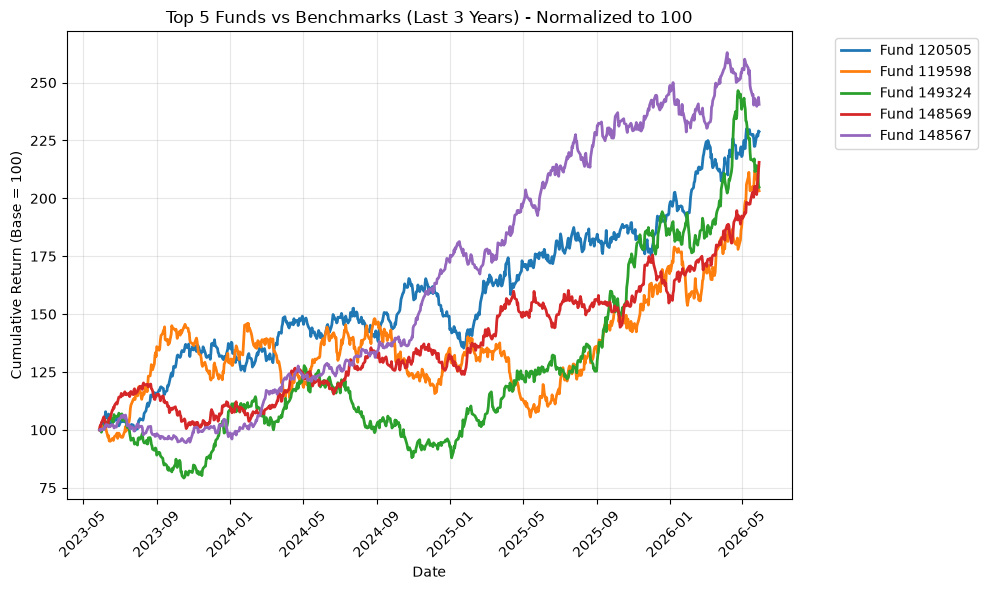

In [15]:
benchmark = pd.read_csv(r"D:\BlueStock_Project\Data\Processed\10_benchmark_indices_cleaned_1.csv")
benchmark['date'] = pd.to_datetime(benchmark['date'])

# Get top 5 funds by 3Y CAGR
top_5 = cagr_df.nlargest(5, 'CAGR_3yr')['amfi_code'].tolist()

# Prepare data for last 3 years
end_date = nav['date'].max()
start_date = end_date - pd.DateOffset(years=3)

plot_data = nav[nav['date'] >= start_date].copy()

plt.figure(figsize=(10,6))

# Plot top 5 funds
for code in top_5:
    data = plot_data[plot_data['amfi_code'] == code]
    plt.plot(data['date'], data['nav'] / data['nav'].iloc[0] * 100, label=f'Fund {code}', linewidth=2)

# Plot benchmarks (assuming they exist in benchmark df)
for bench_name in ['Nifty50', 'Nifty100']:  # Adjust column names as per your benchmark file
    if bench_name in benchmark.columns:
        b_data = benchmark[benchmark['date'] >= start_date]
        plt.plot(b_data['date'], b_data[bench_name] / b_data[bench_name].iloc[0] * 100, 
                 label=bench_name, linestyle='--', linewidth=2.5)

plt.title("Top 5 Funds vs Benchmarks (Last 3 Years) - Normalized to 100")
plt.xlabel("Date")
plt.ylabel("Cumulative Return (Base = 100)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()